In [1]:
import pandas as pd # Carga la librería para manejar tablas de datos (DataFrames).
import os # Permite interactuar con el sistema operativo (gestionar carpetas y rutas de archivos).
import sys # Proporciona acceso a variables y funciones que interactúan con el intérprete de Python.
!{sys.executable} -m pip install mlflow
import mlflow # Carga MLflow para registrar los experimentos del modelo.
import numpy as np # Carga la librería para realizar operaciones matemáticas y matrices.
from sklearn.preprocessing import StandardScaler # Transforma los datos para que tengan media 0 y varianza 1 (escalamiento indispensable para clustering).
import matplotlib.pyplot as plt # Biblioteca fundamental para la creación de gráficos y visualizaciones estáticas en Python.
from sklearn.cluster import KMeans # Carga el algoritmo de K-Means para segmentar y agrupar los datos en clústeres.
from sklearn.metrics import silhouette_score # Calcula el coeficiente de silueta para evaluar matemáticamente la calidad y separación de los clústeres.
import matplotlib.patches as patches # Permite dibujar formas geométricas avanzadas (como las elipses de confianza en tus gráficos).
from sklearn.decomposition import PCA # Aplica Análisis de Componentes Principales para reducir la dimensionalidad de los datos sin perder información clave.
from mlxtend.frequent_patterns import apriori, association_rules # Carga las funciones del algoritmo Apriori y sus reglas.
import warnings # Carga la librería para controlar los mensajes de alerta de Python.




In [2]:
# 1. CARGA DE DATOS
# Cargar los datos limpios exportados del EDA
df_detalle = pd.read_csv(r'C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\data\datos_tostao_limpios.csv')

# Convertir la fecha a tipo datetime para que mantenga sus propiedades organizadas
df_detalle['fecha'] = pd.to_datetime(df_detalle['fecha'])

print(f"¡Datos cargados correctamente en el nuevo Notebook! Total de registros: {len(df_detalle)}")
df_detalle.head()

¡Datos cargados correctamente en el nuevo Notebook! Total de registros: 18376


,id_ticket,id_producto,cantidad,precio_unitario,nombre,categoria,subcategoria,fecha,id_tienda,id_cliente,venta_total,mes,dia_semana
0,TICKET_000001,PROD_030,1,4500,Torta de Zanahoria,Alimentos,Panadería Dulce,2024-08-29,TOSTAO_15,CUST_01364,4500,August,Thursday
1,TICKET_000002,PROD_006,1,2500,Aromática,Bebidas,Calientes,2024-02-04,TOSTAO_18,CUST_01956,2500,February,Sunday
2,TICKET_000003,PROD_033,1,1500,Chocolatina,Alimentos,Panadería Dulce,2024-02-23,TOSTAO_18,CUST_01501,1500,February,Friday
3,TICKET_000003,PROD_021,1,3500,Pastel de Pollo,Alimentos,Panadería Sal,2024-02-23,TOSTAO_18,CUST_01501,3500,February,Friday
4,TICKET_000004,PROD_019,1,3200,Empanada de Carne,Alimentos,Panadería Sal,2024-10-30,TOSTAO_08,CUST_01276,3200,October,Wednesday


In [3]:
# 2. DIVISIÓN DE LOS DATOS (TRAIN - TEST)

# Aseguramor el orden cronológico absoluto de las transacciones
df_ordenado = df_detalle.sort_values(by='fecha').reset_index(drop=True)  # Ordena las filas desde la fecha más vieja a la más nueva y reinicia los índices.

# 2. Calcular la posición exacta para el corte del 80%
punto_corte = int(len(df_ordenado) * 0.80)                             # Encuentra la posición del registro que representa el 80% de toda la data.
fecha_corte = df_ordenado.iloc[punto_corte]['fecha']                    # Extrae la fecha exacta en la que se cumple ese 80% del tiempo.

# 3. Dividir el conjunto de datos
df_train_raw = df_ordenado.iloc[:punto_corte].copy()                    # Corta y guarda el primer 80% de los datos (el pasado) para entrenar el modelo.
df_test_raw = df_ordenado.iloc[punto_corte:].copy()                     # Corta y guarda el 20% restante de los datos (el futuro) para validar el modelo.

# 4. Métricas para auditar la división
total_filas = len(df_ordenado)                                          # Cuenta la cantidad total de filas que tiene el conjunto de datos completo.
filas_train = len(df_train_raw)                                         # Cuenta cuántos registros quedaron asignados al bloque de entrenamiento.
filas_test = len(df_test_raw)                                           # Cuenta cuántos registros quedaron asignados al bloque de prueba.
print("DIVISIÓN TEMPORAL CRONOLÓGICA")
print(f"Dataset Completo    : {total_filas:,} filas de transacciones")
print(f"Fecha de Corte      : {fecha_corte}")
print("-" * 66)
print(f"Entrenamiento (Train): {filas_train:,} filas ({filas_train/total_filas:.1%})")
print(f"   • Rango de fechas   : Desde {df_train_raw['fecha'].min().strftime('%Y-%m-%d')} hasta {df_train_raw['fecha'].max().strftime('%Y-%m-%d')}")
print("-" * 66)
print(f"Validación (Test)   : {filas_test:,} filas ({filas_test/total_filas:.1%})")
print(f"   • Rango de fechas   : Desde {df_test_raw['fecha'].min().strftime('%Y-%m-%d')} hasta {df_test_raw['fecha'].max().strftime('%Y-%m-%d')}")


DIVISIÓN TEMPORAL CRONOLÓGICA
Dataset Completo    : 18,376 filas de transacciones
Fecha de Corte      : 2024-10-17 00:00:00
------------------------------------------------------------------
Entrenamiento (Train): 14,700 filas (80.0%)
   • Rango de fechas   : Desde 2024-01-01 hasta 2024-10-17
------------------------------------------------------------------
Validación (Test)   : 3,676 filas (20.0%)
   • Rango de fechas   : Desde 2024-10-17 hasta 2024-12-30


In [4]:
# 3. PREPARACIÓN DE DATOS (ONE - HOT ENCODING)

def aplicar_one_hot_encoding(df_insumo: pd.DataFrame) -> pd.DataFrame:
    """
    Transforma el formato transaccional a una estructura matricial
    donde las columnas son los productos y las celdas indican si el
    producto fue comprado (1) o no (0) en cada ticket.
    """
    # 1. Agrupar por ticket y producto sumando cantidades
    matriz_pivot = df_insumo.groupby(['id_ticket', 'nombre'])['cantidad'].sum().unstack().reset_index().fillna(0)  # Agrupar los datos por ticket y nombre de producto, pivotar la tabla y rellenar valores nulos con cero.
    
    # 2. Establecer el id_ticket como índice de la matriz
    matriz_pivot.set_index('id_ticket', inplace=True)                                                               # Asignar de forma definitiva la columna del identificador del ticket como el índice principal de la matriz.
    
    # 3. Codificación binaria: Si la cantidad es mayor a 0 se asigna 1, si no 0
    matriz_binaria = matriz_pivot.map(lambda x: 1 if x > 0 else 0)                                                  # Evaluar cada celda para transformar cualquier cantidad comprada en un uno (1) y la ausencia de compra en cero (0).
    
    return matriz_binaria                                                                                           # Retornar la matriz de transacciones binarias completamente procesada y lista para aplicar el algoritmo Apriori.


print("ONE-HOT ENCODING MULTI-DATASET")


# Aplicar la transformación de canasta a Train y Test por separado
basket_train = aplicar_one_hot_encoding(df_train_raw)
basket_test = aplicar_one_hot_encoding(df_test_raw)

print(f"Dimensiones de la matriz de Train : {basket_train.shape[0]} tickets x {basket_train.shape[1]} productos")
print(f"Dimensiones de la matriz de Test  : {basket_test.shape[0]} tickets x {basket_test.shape[1]} productos")



ONE-HOT ENCODING MULTI-DATASET
Dimensiones de la matriz de Train : 7991 tickets x 35 productos
Dimensiones de la matriz de Test  : 2010 tickets x 35 productos


In [5]:
# Exportar las matrices binarias (One-Hot Encoded) a formato CSV
basket_train.to_csv('train_basket.csv')
basket_test.to_csv('test_basket.csv')

print("Archivo guardado de manera exitosa: 'train_basket.csv'")
print("Archivo guardado de manera exitosa: 'test_basket.csv'")



Archivo guardado de manera exitosa: 'train_basket.csv'
Archivo guardado de manera exitosa: 'test_basket.csv'


In [6]:
# CONFUGIRACIÓN DE MLFLOW PARA LOS EXPERIMENTOS

# Definir la ruta absoluta directa a la raíz del proyecto (fuera de notebooks)
MLRUNS_DIR = r"C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\mlruns"

# Configuración de URI y Experimento
mlflow.set_tracking_uri(f"file:///{MLRUNS_DIR}")
mlflow.set_experiment("Market_Basket_Tostao")

print("¡Entorno de MLflow inicializado correctamente!")
print(f"Tracking de experimentos activo en: {MLRUNS_DIR}")


¡Entorno de MLflow inicializado correctamente!
Tracking de experimentos activo en: C:\Users\nata_\Documents\MLOps\Introduction_to_MLOps\proyecto_2\Combos_Tostao\mlruns


c:\Users\nata_\anaconda3\envs\my_env\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [7]:
# Se utiliza 'df_detalle' que contiene tus 18,376 filas con la información de transacciones
df_perfil_ticket = df_detalle.groupby('id_ticket').agg(
    monto_total=('venta_total', 'sum'),           # Dimensión Económica
    total_articulos=('cantidad', 'sum'),          # Dimensión de Volumen
    categorias_distintas=('categoria', 'nunique') # Dimensión de Diversidad
).reset_index()

print("Estructura de las variables del EDA para el Clustering:")
print(df_perfil_ticket[['monto_total', 'total_articulos', 'categorias_distintas']].describe())
print("\n" + "="*50 + "\n")

# PREPROCESAMIENTO: Tratamiento de Outliers (Método IQR para acotar extremos)
q_monto = df_perfil_ticket['monto_total'].quantile(0.99)
q_articulos = df_perfil_ticket['total_articulos'].quantile(0.99)

# Capamos los datos al percentil 99 para suavizar el peso de compras masivas/corporativas
df_perfil_ticket['monto_total'] = np.where(df_perfil_ticket['monto_total'] > q_monto, q_monto, df_perfil_ticket['monto_total'])
df_perfil_ticket['total_articulos'] = np.where(df_perfil_ticket['total_articulos'] > q_articulos, q_articulos, df_perfil_ticket['total_articulos'])

# PREPROCESAMIENTO: Escalamiento Estándar (Z-score)
# Obligatorio para que K-Means no ignore la cantidad de categorías por culpa de los montos en pesos
features_clustering = ['monto_total', 'total_articulos', 'categorias_distintas']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_perfil_ticket[features_clustering])

# Crear el DataFrame transformado para verificar que la escala esté correcta
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("¡Preprocesamiento Listo! Datos normalizados para el algoritmo:")
df_scaled.head()

Estructura de las variables del EDA para el Clustering:
        monto_total  total_articulos  categorias_distintas
count  10000.000000     10000.000000          10000.000000
mean    6535.700000         1.889400              1.477600
std     3584.818629         0.938646              0.499523
min     1500.000000         1.000000              1.000000
25%     3500.000000         1.000000              1.000000
50%     6000.000000         2.000000              1.000000
75%     8800.000000         2.000000              2.000000
max    21000.000000         4.000000              2.000000


¡Preprocesamiento Listo! Datos normalizados para el algoritmo:


,monto_total,total_articulos,categorias_distintas
0,-0.571382,-0.947583,-0.95616
1,-1.137051,-0.947583,-0.95616
2,-0.429965,0.117835,-0.95616
3,-0.939067,-0.947583,-0.95616
4,-0.345114,0.117835,1.04585


   • Configuración K=2 calculada.
   • Configuración K=3 calculada.
   • Configuración K=4 calculada.
   • Configuración K=5 calculada.
   • Configuración K=6 calculada.
   • Configuración K=7 calculada.
   • Configuración K=8 calculada.


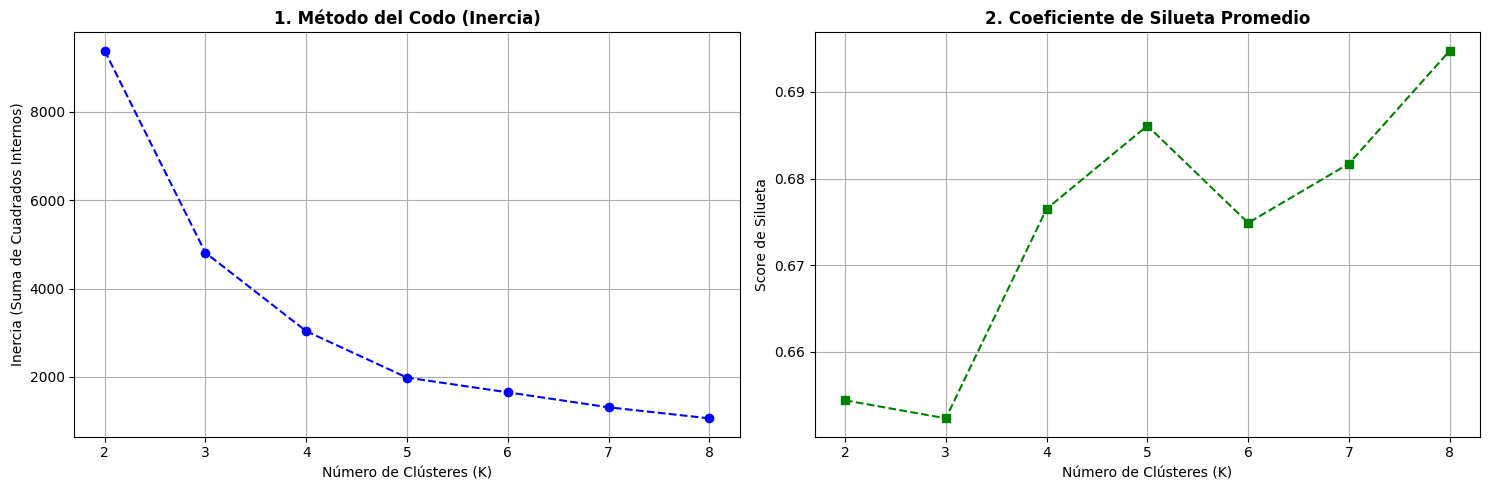

In [8]:
# 5. K - MEANS

# Iniciar las listas para guardar las métricas
inercias = []
siluetas = []
rango_k = range(2, 9)  # desde K=2 hasta K=8 clústeres

# Iterar sobre el rango de clústeres
for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Guardar Inercia (para el Método del Codo)
    inercias.append(kmeans.inertia_)
    
    # Guardar Score de Silueta (Tomamos una muestra si el dataset es muy grande
    score_silueta = silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42)
    siluetas.append(score_silueta)
    print(f"   • Configuración K={k} calculada.")

# Graficar los resultados en paralelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Método del Codo (Inercia)
ax1.plot(rango_k, inercias, marker='o', color='b', linestyle='--')
ax1.set_title('1. Método del Codo (Inercia)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia (Suma de Cuadrados Internos)')
ax1.set_xticks(rango_k)
ax1.grid(True)

# Gráfica 2: Método de la Silueta
ax2.plot(rango_k, siluetas, marker='s', color='g', linestyle='--')
ax2.set_title('2. Coeficiente de Silueta Promedio', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Clústeres (K)')
ax2.set_ylabel('Score de Silueta')
ax2.set_xticks(rango_k)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Definir los dos experimentos que quieres contrastar
configuraciones_k = [3, 4]  

for k in configuraciones_k:
    # Iniciar un experimento en MLflow para cada K
    with mlflow.start_run(run_name=f"KMeans_Experimento_K{k}"):
        
        # 1. Entrenar el modelo
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        # 2. Calcular métricas de validación
        inercia = kmeans.inertia_
        silueta = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
        
        # Asignar temporalmente al DataFrame para analizar la distribución
        df_perfil_ticket[f'cluster_k{k}'] = labels
        distribucion = df_perfil_ticket[f'cluster_k{k}'].value_counts().to_dict()
        
        # 3. Registrar parámetros y métricas en MLflow para el profesor
        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("inertia", inercia)
        mlflow.log_metric("silhouette_score", silueta)
        
        # 4. Mostrar resultados en consola
        print(f"EXPERIMENTO CON K = {k}")
        print(f"   • Inercia: {inercia:.2f}")
        print(f"   • Score de Silueta: {silueta:.4f}")
        print(f"   • Distribución de tickets por clúster:")
        for cluster, conteo in sorted(distribucion.items()):
            porcentaje = (conteo / len(df_perfil_ticket)) * 100
            print(f"     - Clúster {cluster}: {conteo} tickets ({porcentaje:.1f}%)")
        print("\n" + "="*60 + "\n")

EXPERIMENTO CON K = 3
   • Inercia: 4811.69
   • Score de Silueta: 0.6523
   • Distribución de tickets por clúster:
     - Clúster 0: 5065 tickets (50.6%)
     - Clúster 1: 2240 tickets (22.4%)
     - Clúster 2: 2695 tickets (27.0%)


EXPERIMENTO CON K = 4
   • Inercia: 3036.04
   • Score de Silueta: 0.6765
   • Distribución de tickets por clúster:
     - Clúster 0: 4263 tickets (42.6%)
     - Clúster 1: 2062 tickets (20.6%)
     - Clúster 2: 2725 tickets (27.3%)
     - Clúster 3: 950 tickets (9.5%)




In [10]:
# Ejecutar el modelo definitivo con K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_perfil_ticket['cluster_final'] = kmeans_final.fit_predict(X_scaled)

# CARACTERIZACIÓN: Calcular los promedios reales de cada variable por clúster
resumen_clusters = df_perfil_ticket.groupby('cluster_final').agg(
    total_tickets=('id_ticket', 'count'),
    monto_promedio=('monto_total', 'mean'),
    articulos_promedio=('total_articulos', 'mean'),
    categorias_promedio=('categorias_distintas', 'mean')
).reset_index()

# Calcular el porcentaje de participación
resumen_clusters['participacion_%'] = (resumen_clusters['total_tickets'] / resumen_clusters['total_tickets'].sum()) * 100

print("CARACTERIZACIÓN DE LOS 4 CLÚSTERES DEFINITIVOS:")
print(resumen_clusters.round(2).to_string(index=False))

CARACTERIZACIÓN DE LOS 4 CLÚSTERES DEFINITIVOS:
 cluster_final  total_tickets  monto_promedio  articulos_promedio  categorias_promedio  participacion_%
             0           4263         3508.00                1.00                 1.00            42.63
             1           2062        11864.26                3.37                 1.99            20.62
             2           2725         6869.32                2.07                 2.00            27.25
             3            950         7436.21                2.15                 1.00             9.50


In [11]:
# Cargar a MLFLOW
mlflow.set_experiment("Experimentos_KMeans_Clustering")

with mlflow.start_run(run_name="Visualizacion_Clusters_PCA"):
    # Guardas tus parámetros del K-Means
    mlflow.log_param("n_clusters", 4)
    mlflow.log_param("algoritmo", "K-Means + PCA")
    
    plt.savefig("proyeccion_clusters.png", bbox_inches='tight')
    mlflow.log_artifact("proyeccion_clusters.png")
    
    plt.show()

<Figure size 640x480 with 0 Axes>

C:\Users\nata_\AppData\Local\Temp\ipykernel_15516\625784680.py:47: RuntimeWarning: invalid value encountered in sqrt
  ancho, alto = 2 * 2 * np.sqrt(valores_propios) # 2 desviaciones estándar


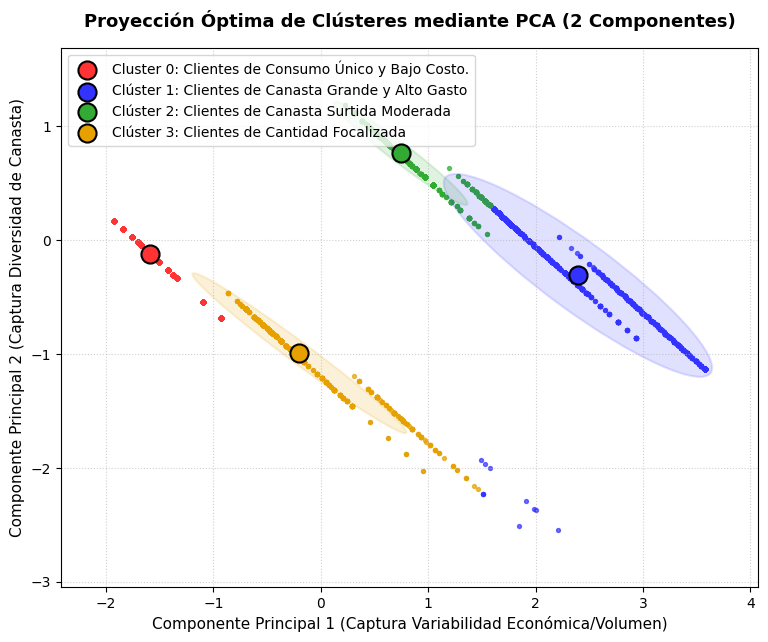

In [12]:
# Visualización de Clusters

# Aplicar PCA para reducir las 3 variables escaladas a 2 dimensiones óptimas
# Cambiado a 'n_components=2' que es el argumento correcto para PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
labels = df_perfil_ticket['cluster_final'].values

# Calcular los nuevos centroides en el espacio PCA
centroides_pca = np.array([X_pca[labels == i].mean(axis=0) for i in range(4)])

# 2. Configurar el lienzo idéntico a tu imagen exitosa
plt.figure(figsize=(9, 7))
ax = plt.subplot(111)

colores = {0: '#FF3333', 1: '#3333FF', 2: '#33AA33', 3: '#E6A100'} 
etiquetas = {
    0: 'Cluster 0: Clientes de Consumo Único y Bajo Costo.',
    1: 'Clúster 1: Clientes de Canasta Grande y Alto Gasto',
    2: 'Clúster 2: Clientes de Canasta Surtida Moderada',
    3: 'Clúster 3: Clientes de Cantidad Focalizada'
}

# Graficar los puntos en el nuevo espacio óptimo
for i in range(4):
    plt.scatter(
        X_pca[labels == i, 0], 
        X_pca[labels == i, 1], 
        s=8, 
        c=colores[i], 
        alpha=0.7
    )

# Dibujar las elipses y centroides sobre el espacio PCA
for i in range(4):
    puntos_cluster = X_pca[labels == i]
    centro = centroides_pca[i]
    
    # Calcular la matriz de covarianza para inclinar las elipses según la dispersión real
    cov = np.cov(puntos_cluster.T)
    valores_propios, vectores_propios = np.linalg.eig(cov)
    orden = np.argsort(valores_propios)[::-1]
    valores_propios, vectores_propios = valores_propios[orden], vectores_propios[:, orden]
    
    # Ángulo de inclinación de la elipse
    angulo = np.degrees(np.arctan2(*vectores_propios[:, 0][::-1]))
    ancho, alto = 2 * 2 * np.sqrt(valores_propios) # 2 desviaciones estándar
    
    # Dibujar elipse con la inclinación real del grupo
    elipse = patches.Ellipse(
        xy=centro, width=ancho, height=alto, angle=angulo,
        edgecolor=colores[i], facecolor=colores[i], alpha=0.15, linewidth=1.5
    )
    ax.add_patch(elipse)
    
    # Dibujar el centroide con su borde negro característico
    plt.scatter(
        centro[0], centro[1], s=170, c=colores[i], 
        edgecolor='black', linewidth=1.5, zorder=10, label=etiquetas[i]
    )

plt.title('Proyección Óptima de Clústeres mediante PCA (2 Componentes)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1 (Captura Variabilidad Económica/Volumen)', fontsize=11)
plt.ylabel('Componente Principal 2 (Captura Diversidad de Canasta)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10, frameon=True)

plt.xlim(X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5)
plt.ylim(X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5)

plt.show()

In [13]:
# 6. ALGORITMO APRIORI - Market Basket Analysis

# Silenciar por completo las advertencias molestas de Python y pandas
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Configuración de MLflow
mlflow.set_experiment("Experimentos_Apriori_Por_Cluster_Definitivo")

nombres_clusters = {
    0: "Clientes de Consumo Único y Bajo Costo",
    1: "Clientes de Canasta Grande y Alto Gasto",
    2: "Clientes de Canasta Surtida Moderada",
    3: "Clientes de Cantidad Focalizada"
}

for cluster_id in sorted(df_perfil_ticket['cluster_final'].unique()):
    
    min_support_config = 0.01  
    min_threshold_lift = 1.0   
    nombre_run = f"Apriori_Productos_Cluster_{cluster_id}_{nombres_clusters[cluster_id]}"
    
    with mlflow.start_run(run_name=nombre_run):
        
        # Filtrado de datos por clúster
        tickets_del_cluster = df_perfil_ticket[df_perfil_ticket['cluster_final'] == cluster_id]['id_ticket']
        df_detalle_filtrado = df_detalle[df_detalle['id_ticket'].isin(tickets_del_cluster)]
        
        # Usar .map en lugar de .applymap para evitar futuras advertencias
        matriz_transaccional = pd.crosstab(df_detalle_filtrado['id_ticket'], df_detalle_filtrado['nombre'])
        matriz_binaria = matriz_transaccional.map(lambda x: 1 if x > 0 else 0)
        
        total_reglas = 0
        max_lift = 0.0
        max_confidence = 0.0
        
        # Ejecución del algoritmo
        frequent_itemsets = apriori(matriz_binaria, min_support=min_support_config, use_colnames=True)
        
        print(f"CLÚSTER {cluster_id}: {nombres_clusters[cluster_id].upper()}")
        
        if not frequent_itemsets.empty:
            reglas = association_rules(frequent_itemsets, metric="lift", min_threshold=min_threshold_lift)
            total_reglas = len(reglas)
            
            if total_reglas > 0:
                max_lift = reglas['lift'].max()
                max_confidence = reglas['confidence'].max()
                
                # Ordenar por el Lift más fuerte
                reglas = reglas.sort_values(by='lift', ascending=False).reset_index(drop=True)
                
                print(f"   (Se encontraron {total_reglas} reglas en total. Mostrando el Top 10 más fuerte):")
                
                # Tomar el Top 10 (o menos si no alcanza a 10)
                top_reglas = reglas.head(10)
                for idx, row in top_reglas.iterrows():
                    ant = list(row['antecedents'])
                    cons = list(row['consequents'])
                    print(f"   [{idx+1}] {ant} -> {cons} | Confianza: {row['confidence']:.2f} | Lift: {row['lift']:.2f}")
            else:
                print("No hay reglas con Lift > 1.0")
        else:
            print("No se detectaron productos frecuentes con soporte >= 1%")
            
        # Registro en MLflow
        mlflow.log_param("cluster_id", cluster_id)
        mlflow.log_param("perfil_cliente", nombres_clusters[cluster_id])
        mlflow.log_param("min_support", min_support_config)
        mlflow.log_metric("total_reglas", total_reglas)
        mlflow.log_metric("max_lift", max_lift)
        mlflow.log_metric("max_confidence", max_confidence)
        
        print("-" * 60)

CLÚSTER 0: CLIENTES DE CONSUMO ÚNICO Y BAJO COSTO
No hay reglas con Lift > 1.0
------------------------------------------------------------
CLÚSTER 1: CLIENTES DE CANASTA GRANDE Y ALTO GASTO
   (Se encontraron 76 reglas en total. Mostrando el Top 10 más fuerte):
   [1] ['Galleta de Chispas'] -> ['Aromática'] | Confianza: 0.55 | Lift: 6.39
   [2] ['Aromática'] -> ['Galleta de Chispas'] | Confianza: 0.51 | Lift: 6.39
   [3] ['Avena'] -> ['Buñuelo'] | Confianza: 0.66 | Lift: 4.98
   [4] ['Buñuelo'] -> ['Avena'] | Confianza: 0.88 | Lift: 4.98
   [5] ['Almojábana', 'Rollo de Canela'] -> ['Café con Leche'] | Confianza: 0.95 | Lift: 4.97
   [6] ['Café con Leche'] -> ['Almojábana', 'Rollo de Canela'] | Confianza: 0.05 | Lift: 4.97
   [7] ['Café con Leche', 'Rollo de Canela'] -> ['Almojábana'] | Confianza: 0.68 | Lift: 4.61
   [8] ['Almojábana'] -> ['Café con Leche', 'Rollo de Canela'] | Confianza: 0.07 | Lift: 4.61
   [9] ['Rollo de Canela', 'Gaseosa 400ml'] -> ['Empanada de Carne'] | Confianz

In [17]:

# 7. COMBOS FINALES 

warnings.filterwarnings("ignore")  # Silencia y oculta todas las advertencias visuales en la consola.

# Define el nombre del experimento general en el panel de MLflow.
mlflow.set_experiment("Reporte_Final_Combos_Estrategicos")

clusters_analisis = [1, 2, 3]  # Guarda los IDs de los clústeres que sí tienen compras múltiples.
nombres_format = {
    1: "Clientes de Canasta Grande y Alto Gasto",
    2: "Clientes de Canasta Surtida Moderada",
    3: "Clientes de Cantidad Focalizada"
}

dias_espanol = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}

print("GENERANDO REPORTE DE COMBOS TOP 5 CON TIENDAS Y DÍAS\n")

for clus in clusters_analisis:
    with mlflow.start_run(run_name=f"Combos_Contexto_Cluster_{clus}"):

        tickets_clus = df_perfil_ticket[df_perfil_ticket['cluster_final'] == clus]['id_ticket']
        df_det_clus = df_detalle[df_detalle['id_ticket'].isin(tickets_clus)].copy()
        df_det_clus['nombre_dia'] = df_det_clus['fecha'].dt.day_name().map(dias_espanol)

        matriz = pd.crosstab(df_det_clus['id_ticket'], df_det_clus['nombre']).map(lambda x: 1 if x > 0 else 0)

        freq_items = apriori(matriz, min_support=0.01, use_colnames=True)
        reglas = association_rules(freq_items, metric="lift", min_threshold=1.0)

        print(f"COMBOS PARA CLÚSTER {clus}: {nombres_format[clus].upper()}")
        print("=" * 85)

        if not reglas.empty:

           
            # ELIMINAR COMBOS DUPLICADOS (A → B y B → A)
            

            # 1. Convertir antecedente + consecuente en un combo ordenado
            reglas['combo'] = reglas.apply(
                lambda row: tuple(sorted(list(row['antecedents']) + list(row['consequents']))),
                axis=1
            )

            # 2. Ordenar por lift (o score si lo usas)
            reglas = reglas.sort_values(by='lift', ascending=False)

            # 3. Eliminar duplicados conservando la regla más fuerte
            reglas = reglas.drop_duplicates(subset='combo', keep='first')

            # 4. Resetear índice para que los combos queden numerados 0,1,2,3,4
            reglas = reglas.reset_index(drop=True)

        
            # Tomar el Top 5 limpio
            top_5 = reglas.head(5)

            for idx, row in top_5.iterrows():
                ant = list(row['antecedents'])
                cons = list(row['consequents'])
                combo_completo = list(set(ant + cons))

                tickets_con_combo = matriz[matriz[combo_completo].all(axis=1)].index
                df_combo_contexto = df_det_clus[df_det_clus['id_ticket'].isin(tickets_con_combo)]
                contexto_unico_ticket = df_combo_contexto.drop_duplicates(subset=['id_ticket'])

                if not contexto_unico_ticket.empty:
                    top_tiendas = contexto_unico_ticket['id_tienda'].value_counts().head(3).index.tolist()
                    top_tiendas_str = ", ".join([str(t) for t in top_tiendas])
                    dia_fuerte = contexto_unico_ticket['nombre_dia'].mode()[0]
                else:
                    top_tiendas_str = "N/A"
                    dia_fuerte = "N/A"

                print(f"Combo #{idx+1}: {' + '.join(combo_completo)}")
                print(f"   🔹 Confianza: {row['confidence']:.2f} | Lift: {row['lift']:.2f}")
                print(f" IDs Tiendas Top: {top_tiendas_str}")
                print(f" Día Clave:      {dia_fuerte}")
                print("-" * 85)

                mlflow.log_param(f"combo_{idx+1}_productos", " + ".join(combo_completo))
                mlflow.log_param(f"combo_{idx+1}_tiendas_top", top_tiendas_str)
                mlflow.log_param(f"combo_{idx+1}_dia_semana", str(dia_fuerte))

        else:
            print("No se encontraron reglas de asociación para este clúster.")
        print("\n")


GENERANDO REPORTE DE COMBOS TOP 5 CON TIENDAS Y DÍAS

COMBOS PARA CLÚSTER 1: CLIENTES DE CANASTA GRANDE Y ALTO GASTO
Combo #1: Galleta de Chispas + Aromática
   🔹 Confianza: 0.55 | Lift: 6.39
 IDs Tiendas Top: TOSTAO_13, TOSTAO_10, TOSTAO_03
 Día Clave:      Martes
-------------------------------------------------------------------------------------
Combo #2: Avena + Buñuelo
   🔹 Confianza: 0.66 | Lift: 4.98
 IDs Tiendas Top: TOSTAO_14, TOSTAO_20, TOSTAO_15
 Día Clave:      Domingo
-------------------------------------------------------------------------------------
Combo #3: Almojábana + Rollo de Canela + Café con Leche
   🔹 Confianza: 0.95 | Lift: 4.97
 IDs Tiendas Top: TOSTAO_13, TOSTAO_03, TOSTAO_08
 Día Clave:      Sábado
-------------------------------------------------------------------------------------
Combo #4: Empanada de Carne + Rollo de Canela + Gaseosa 400ml
   🔹 Confianza: 0.66 | Lift: 4.36
 IDs Tiendas Top: TOSTAO_19, TOSTAO_13, TOSTAO_10
 Día Clave:      Domingo
------